<div class="alert alert-block alert-success">
    <b>Dynamical Systems Analysis</b>
    <p>In this notebook, we will consider a system of differential equations that represent a biological system of events. After exploring the behavior of the system over tmie, we will plot and use mathmatical anaylsis in an attempt to uncover the system at hand. </p>
    <p><b>NB:</b> consider how a mathmatical model can be used as a basis algorithm to simulate a real-world scenario of complexity. We will explore points of stability (or equilibria) in this analysis.</p>
</div>

Necessary imports

In [1]:
from random import expovariate # Generate variates from exponential distribution
import numpy as np
#import pylab as p
import matplotlib.pyplot as plt
from scipy.integrate import odeint
#from scipy.optimize import fsolve
from pylab import rcParams
import sympy as sym
from scipy import sqrt
from random import expovariate # Generate variates from exponential distribution
import pandas as pd

### create plots to represent Dynamics in Time and Phase-Portrait for values of limit parameters

#### define function to handle our ODEs with various start values

In [2]:
# define system in terms of a Numpy array
#return our two ODEs
def dydt_FHN(Y, time=0): #param Y is the integrated system, param time is defined outside our function
    A=Y[0] #assign A to the first element in Y
    B=Y[1] #assign B to the second element in Y
    dydt=np.array([-beta*(B/N)*A + gamma*B, beta*(B/N)*A - gamma*B]) #make an array of the ODEs
    return dydt #return the array which will be saved in variable Y

- plot code and essential variable declarations
- show system (A and B) over time and display phase portrait

time sequence ranges from -10.0 to 10.0 with a length of 100.
We started with the initial values of:
	A=800,B=200,beta=2,gamma=1



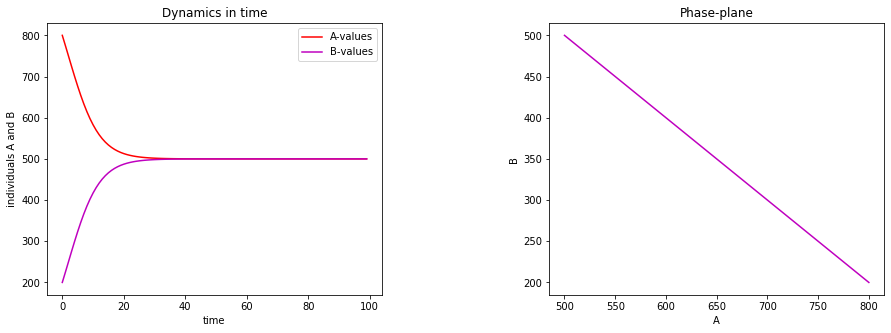

In [3]:
# generate 1000 linearly spaced numbers from 0 to 20 which will be represented in x-axis of 'dynamics in time' plot
time = np.linspace(-10, 10,  100) #use this var to pass into dydt_FHN function
#inital values
N=1000 #number of individuals (population)
B0=200 #remember that A + B = N (so, B must be the difference of N and A)
A0=N-B0 #remember that A + B = N (so, A must be the difference of N and B)
beta=2 #beta rate
gamma=1 #gamma rate
Y0 = np.array([A0, B0]) #we start with an inital position containing intial values of A and B
Y = odeint(dydt_FHN, Y0, time) #get integrated ODE using python odeint function
A,B = Y.T #prints the first two tuples, which are the integration for A0 and B0 respectively
equilibria=[[N,0],[(N*gamma)/beta,(N*(beta-gamma))/beta],[0,0]] #we calculated this analytically


'''plot'''
#customise some of the plot
fig = plt.figure(figsize=(15,5))
fig.subplots_adjust(wspace = 0.5, hspace = 0.3)
axdt1 = fig.add_subplot(1,2,1)
axpp1 = fig.add_subplot(1,2,2)

#plot dynamics in time i.e., plotting time against 
axdt1.plot(A, 'r-', label='A-values')
axdt1.plot(B, 'm-', label='B-values')
axdt1.set_xlabel("time")
axdt1.set_ylabel("individuals A and B")
axdt1.set_title("Dynamics in time")
axdt1.legend(loc='best')

#plot phase portrait i.e., plotting A against B
axpp1.plot(A, B, 'm')
axpp1.set_xlabel("A")
axpp1.set_ylabel("B")  
axpp1.set_title("Phase-plane")

#print some details about the plots for ease
print("time sequence ranges from {} to {} with a length of {}.\n"
        "We started with the initial values of:\n\tA={},B={},beta={},gamma={}\n"
        "".format(time[0],time[len(time)-1],len(time),A0,B0,beta,gamma))

### user input for values of limit parameters
Below you can ask the machine to prompt you to enter values of key parameters N, B0, beta, and gamma. R0 and A0 are calculated for you. Use this functionality to verify plots in simulation part are displaying properly. Plots in simulation part, after various scenario and realisation manipulations, should behave simular to the single lines of A and B plotted in the **Dynamics in Time** plot below.

Enter value for N: 100
Enter value for B0: 80
Enter value for beta: 2
Enter value for gamma: 1

your initial values are:
N=100, A0 (N-B0)=20, B0=80, beta=2, gamma=1, R0 (beta/gamma)=2.0

time sequence ranges from -10.0 to 10.0 with a length of 100.
We started with the initial values of:
	A=20,B=80,beta=2,gamma=1



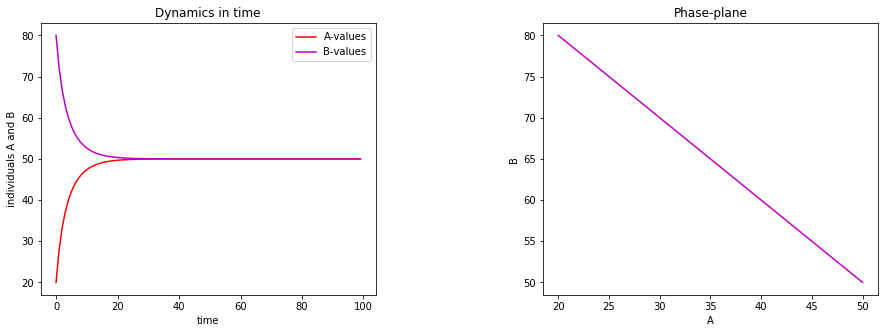

In [4]:
N=input("Enter value for N: ")
N=int(N)
B0=input("Enter value for B0: ")
B0=int(B0)
beta=input("Enter value for beta: ")
beta=int(beta)
gamma=input("Enter value for gamma: ")
gamma=int(gamma)
A0=N-B0
R0=beta/gamma
print("\nyour initial values are:\nN={}, A0 (N-B0)={}, B0={}, beta={}, gamma={}, R0 (beta/gamma)={}".format(
        N,A0,B0,beta,gamma,R0))

'''get ODE values'''
Y0 = np.array([A0, B0]) #we start with an inital position containing intial values of A and B
Y = odeint(dydt_FHN, Y0, time) #get integrated ODE using python odeint function
A,B = Y.T #prints the first two tuples, which are the integration for A0 and B0 respectively
equilibria=[[N,0],[(N*gamma)/beta,(N*(beta-gamma))/beta],[0,0]] #we calculated this analytically

'''plot'''
#customise some of the plot
fig2 = plt.figure(figsize=(15,5))
fig2.subplots_adjust(wspace = 0.5, hspace = 0.3)
axdt2 = fig2.add_subplot(1,2,1)
axpp2 = fig2.add_subplot(1,2,2)

#plot dynamics in time i.e., plotting time against 
axdt2.plot(A, 'r-', label='A-values')
axdt2.plot(B, 'm-', label='B-values')
axdt2.set_xlabel("time")
axdt2.set_ylabel("individuals A and B")
axdt2.set_title("Dynamics in time")
axdt2.legend(loc='best')

#plot phase portrait i.e., plotting A against B
axpp2.plot(A, B, 'm')
axpp2.set_xlabel("A")
axpp2.set_ylabel("B")  
axpp2.set_title("Phase-plane")

#print some details about the plots for ease
print("\ntime sequence ranges from {} to {} with a length of {}.\n"
        "We started with the initial values of:\n\tA={},B={},beta={},gamma={}\n"
        "".format(time[0],time[len(time)-1],len(time),A0,B0,beta,gamma))

Demonstrate stability using nulllclines (or isoclines) and quiver analysis

equilibria are [[100, 0], [50.0, 50.0], [0, 0]] when beta=2,gamma=1
ynullpts=[[50.0, 50.0], [0, 100]], xnullpts=[[100, 0], [0, 100]]


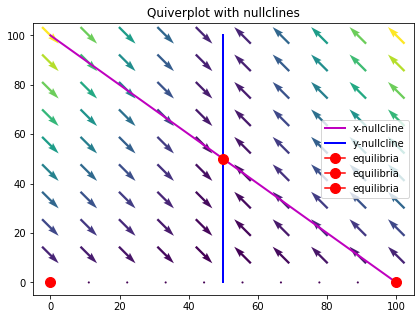

In [5]:
#plot
fig = plt.figure(figsize=(15,5))
ax_fxdpt1 = fig.add_subplot(1,2,1)

# declare and plot nullclines
xnullpts=[[N,0],
          [0,N]]
ynullpts=[[(N*gamma)/beta,(N*gamma)/beta],
          [0,N]]
ax_fxdpt1.plot(xnullpts[0],xnullpts[1],'m', lw=2, label='x-nullcline')
ax_fxdpt1.plot(ynullpts[0],ynullpts[1],'b', lw=2, label='y-nullcline')

# plot fixed points
for point in equilibria:
    ax_fxdpt1.plot(point[0],point[1],"r", marker = "o", markersize = 10.0, label='equilibria')
ax_fxdpt1.set_title("Quiverplot with nullclines")
ax_fxdpt1.legend(loc='best')

# quiverplot
# define a grid and compute direction at each point
x = np.linspace(N, 0, 10)
y = np.linspace(N, 0, 10)

X1, Y1  = np.meshgrid(x, y)# create a grid

DX1, DY1 = dydt_FHN([X1, Y1])# compute growth rate on the grid
M = (np.hypot(DX1, DY1))# norm growth rate 
M[ M == 0] = 1.# avoid zero division errors 
DX1 /= M # normalize each arrows
DY1 /= M

ax_fxdpt1.quiver(X1, Y1, DX1, DY1, M, pivot='mid')
print("equilibria are {} when beta={},gamma={}\nynullpts={}, xnullpts={}".format(
    equilibria,beta,gamma,ynullpts,xnullpts))

#### Bifurcation Plot

need to incorporate euler's method

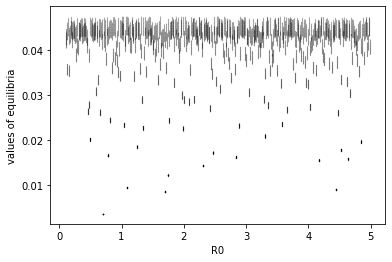

In [6]:
#euler's method: 𝑥 𝑡 + ℎ = 𝑥 𝑡 + ℎ A 𝐹(𝑥 𝑡 , 𝑡)

'''mean-field function'''
def f(x,R0):
    B=x
    #we will use [B]dot as mean-field equation
    bdot = (beta*B)-((beta*B**2)/N)-(gamma*B)

    return bdot # logistic map with parameter r >= 1

def bifurcation(R0, iter):
    
    # One initial condition for each value of r
    #we take an nd-array of random float64s with length taken from R0 ndarray; store them inside variable x
    x = np.random.rand(len(R0))
    
    # We are first going to get rid of the transients
    for i in range(1000):
        x = f(x,R0)

    # Assuming we are now on the limit cycle, we plot value of iter outputs
    for i in range(iter): 
        x = f(x,R0)
        plt.plot(R0,x,'.', color = 'k', markersize = 0.05)
        
'''plot bifurcation'''
plt.figure()
#plt.rcParams['axes.facecolor'] = 'c'
plt.xlabel('R0')
plt.ylabel('values of equilibria')

'''for plotting bifurcation'''
R0 = np.arange(0.1, 5.0, 0.01) #type: nd-array #taking values from 0.1 to 5.0, with increments of 0.01 as required
iter = 100
bifurcation(R0, iter)
plt.show()

### functions for running simulations on Gillespie

In [7]:
def gillespie_ABA(params):
    
    ##this assignment is my own creation, not Luc's
    #assign the list values of params to some local vars
    N=params[0]
    B0=params[1]
    beta=params[2]
    gamma=params[3]
    Tmax=params[4]
    
    A=[N-B0] # We cannot predict how many elements there will be unfortunately
    B=[B0]
    T=[0] ##we start with a list T and first element is = 0.
    ##state is either 0 or 1 at anytime
    state = np.random.permutation([0]*(N-B0)+[1]*B0) # Randomly allocate B0 individuals to have state B (state=1), A (state=0) otherwise 
    B_contacts = np.where(state==1)[0] # Index of individuals in state B (state=1).
    rate_vector = B0*beta*np.ones((N,1))/N # Set rates to be B0*beta/N (rate for individuals in state A) to all individuals (initialisation). 
    rate_vector[B_contacts] = gamma # Update rate of B_contacts to be gamma (the rate for individuals in state B)
    
    time = 0
    while time<=Tmax+0.5: # some (arbitrary) buffer after Tmax
        rate = np.sum(rate_vector) # Total rate (refer to Gillespie algorithm for details)
        cumrate = np.cumsum(rate_vector) # Cumulated sum of rates
        if rate > 0.000001: # if rate is sufficiently large
            tstep = expovariate(rate) # Pick an exponentially distributed time. Beware of difference with exprnd in Matlab where it is 1/rate
            T.append(T[-1]+tstep) # Time of next event
            event = np.where(cumrate>np.random.rand()*rate)[0][0] # Find which individual will see its state change 
            if state[event]==0: # individual is in state A 
                A.append(A[-1]-1) # this state A individual becomes state B so number of state A individuals is decreased
                B.append(B[-1]+1) # obviously, number of state B individuals is increased 
                state[event] = 1 # Update state vector
                rate_vector[event] = gamma # Change rate of individual to B->A rate, namely gamma
                A_contacts = np.where(state==0)[0] # List of state A individuals after change
                rate_vector[A_contacts] += beta/N # Update rate of state A individuals to account for the extra state B individual
            else: # individual is in state B
                B.append(B[-1]-1) # this state B individual becomes state A so number of state B individuals is decreased
                A.append(A[-1]+1) # obviously, number of state A individuals is increased
                state[event] = 0 # Update state vector
                A_contacts = np.where(state==0)[0] # List of state A individuals after changes                                
                rate_vector[A_contacts] = beta*len(np.where(state==1)[0])/N # Update rate of state A individuals based on number of B individuals  
        else: # Nothing will happen from now on so we can accelerate the process
            time = T[-1] # current time
            while time <= Tmax + 0.5:
                A.append(A[-1]) # Just keep things as they are
                B.append(B[-1])
                T.append(T[-1]+0.5) # arbitrarily add 0.5 to clock
                time = T[-1]
        # Update time and proceed with loop 
        time = T[-1]         
    return T,A,B

In [8]:
def get_scenarios(case_length, plot_num, param):
    scenarios=[]
    #manipulation of all key parameters
    if plot_num==1: 
        for i in range(case_length):
            if i!=0:
                scenarios.append([N*i,B0*i,beta*i,gamma*i,Tmax,(beta/gamma)])
    #no manipulation of parameters
    if plot_num==2: 
        for i in range(case_length):
            scenarios.append([N,B0,beta,gamma,Tmax,(beta/gamma)])
    #manipulation of N
    if plot_num==3: 
        for i in range(case_length):
            if i==0:
                scenarios.append([param,B0,beta,gamma,Tmax,(beta/gamma)])
            if (i+1)%(case_length/2)==0:
                scenarios.append([param,B0,beta,gamma,Tmax,(beta/gamma)])
            param+=i
    if plot_num==4: #manipulation of B0
        #increase baseline N by 1000 because we know that A0=N-B0 and we do not want negatives
        for i in range(case_length):
            if i==0:
                scenarios.append([2000,param,beta,gamma,Tmax,(beta/gamma)])
            if (i+1)%(case_length/2)==0:
                scenarios.append([2000,param,beta,gamma,Tmax,(beta/gamma)])
            param+=i
    if plot_num==5: #manipulation of beta
        for i in range(case_length):
            if i==0:
                scenarios.append([N,B0,param,gamma,Tmax,(param/gamma)])
            if (i+1)%(case_length/2)==0:
                param=param*5
                scenarios.append([N,B0,param,gamma,Tmax,(param/gamma)])
    if plot_num==6: #manipulation of beta
        for i in range(case_length):
            if i==0:
                scenarios.append([N,B0,beta,param,Tmax,(beta/param)])
            if (i+1)%(case_length/2)==0:
                param=param*5
                scenarios.append([N,B0,beta,param,Tmax,(beta/param)])
    
    #dataframe using pandas library
    df = pd.DataFrame(scenarios,columns=['N','B0','beta','gamma','Tmax','R0'])
    display(df.head())
    display(df.tail())
    print("table 1; data row x columns is {}".format(df.shape))
    
    return scenarios

def get_avg_std(Blist):
    avg=np.mean(Blist)
    std=np.std(Blist)
    return avg, std

#get the gillespie values and plot them; print pandas frame for reference
def plot_things(plt_run_labels,plt_errorbars,runs,scenarios,param,run=1):
      
    #averages=[]
    if runs=='multiple': #if you want multiple runs of same limit case scenarios
        for i in range(run): #loop for a specified amount of runs
            #declare T, A, B lists to store Gillespie values later on
            Tlist=[]
            Alist=[]
            Blist=[]
            for limit_case in range(len(scenarios)): #for each limit case in scenarios, do something
                #we are inside each limit_case in our scenarios list
                #in here we will iterate the number of times of length(scenarios)
                T, A, B = gillespie_ABA(scenarios[limit_case]) #call algorithm and store returned value
                Tlist.append(T)
                Alist.append(A)
                Blist.append(B)
            if plt_run_labels==True:
                plt.plot(T, B, 'b',label='run {}'.format(i+1),linewidth=0.3)
                #plt.plot(get_avg(Blist[i]), 'r', label='avgs',linewidth=2.0)
                #print(get_avg(Blist[i]))
            elif plt_run_labels==False:
                plt.plot(T, B,linewidth=0.01)
        #print('length of Blist at [0]',len(Blist[0]))
        plt.plot()
        #averages.append(get_avg(Blist)) #get average of b values
        #plot the plot info such as title and label names
        plt.xlabel('time')
        plt.ylabel('B0')
        plt.suptitle('Gillespie over multiple increments of {}'.format(param))
        plt.legend()
        plt.show()
    
    else: #if you want a 'single' run of limit case scenarios
        for limit_case in range(len(scenarios)):
            #we are inside each limit_case in our scenarios list
            #in here we will iterate the number of times of length(scenarios)
            T, A, B = gillespie_ABA(scenarios[limit_case]) #call algorithm passing limit case params;store returned value
            #print('T:\n{}\nB:\n{}\n,iteration: {}\ntype of T,B: {}{}'.format(T,B,limit_case,type(T),type(B)))
            avgb, stdb = get_avg_std(B)
            if plt_errorbars==True:
                plt.errorbar(T, B, label='scenario {}'.format(limit_case),linewidth=0.3,yerr=stdb)
            else:
                plt.errorbar(T, B, label='scenario {}'.format(limit_case),linewidth=0.3)
        #plot the plot info such as title and label names    
        plt.xlabel('time')
        plt.ylabel('B0')
        plt.suptitle('Gillespie over multiple increments of {}'.format(param))
        plt.legend()
        plt.show()

,N,B0,beta,gamma,Tmax,R0
0,100,20,2,0.1,4,20.0
1,100,20,10,0.1,4,100.0
2,100,20,50,0.1,4,500.0


,N,B0,beta,gamma,Tmax,R0
0,100,20,2,0.1,4,20.0
1,100,20,10,0.1,4,100.0
2,100,20,50,0.1,4,500.0


table 1; data row x columns is (3, 6)


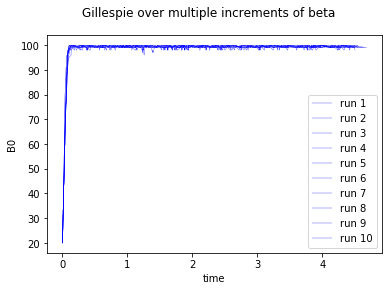

In [9]:
#variable declarations
N=100 #this number will determine how close "T" is
B0=20
beta=2
gamma=0.1
Tmax=4
R0=beta/gamma
scenarios = []

#plot realisations on single plot using inital conditions given by our variable declarations
case_length=50 #give the number of limit cases (variances of limit parameters) you would like to simulate

'''use the code below to manipulate plots with new input values'''
#populate a list of "scenarios" i.e., a list of values that will be passed as parameters into Gillespie algorithm function
#then call function to show plots and tables
plt_errorbars=False #True=plot error bars (i.e., stdev and avg);otherwise False=normal plot
plot_things(True,plt_errorbars,'multiple',get_scenarios(case_length, 5, beta),'beta',10) #'single' for single run, 'multiple' for multiple runs

,N,B0,beta,gamma,Tmax,R0
0,100,20,2,0.1,3,20.0
1,376,20,2,0.1,3,20.0
2,1276,20,2,0.1,3,20.0


,N,B0,beta,gamma,Tmax,R0
0,100,20,2,0.1,3,20.0
1,376,20,2,0.1,3,20.0
2,1276,20,2,0.1,3,20.0


table 1; data row x columns is (3, 6)


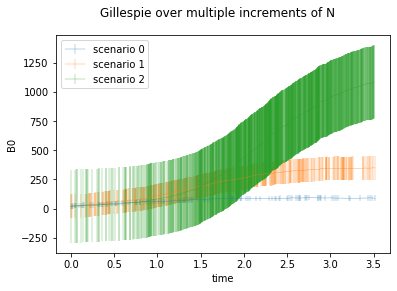

In [10]:
'''below implementation for the case where you want to plot stdev and avg'''
Tmax=3 #change Tmax to smaller size if needed
plt_errorbars=True #True=plot error bars (i.e., stdev and avg);otherwise False=normal plot
plot_things(True,
            plt_errorbars,
            'single', #'single' for single run, 'multiple' for multiple runs
            get_scenarios(case_length, 3, N),
            'N') 